# 06 — Spatial model diagnostics

**Purpose:** Analyze spatial behavior of model errors after spatial cross-validation.

We load the dataset, train a baseline model with **SpatialGroupKFold**, compute residuals (observed − predicted), and then:
- Map residuals in space (diverging colormap)
- Inspect residual distribution (histogram, KDE, bias, skewness)
- Plot residuals vs key environmental variables with LOWESS
- Compute Moran's I on residuals (remaining spatial structure)
- Show feature importance from a full-data model
- Interpret patterns and implications for generalization

# 1. Train baseline model with SpatialGroupKFold

Same pipeline as in previous notebooks: load dataset, build feature matrix, run **SpatialGroupKFold**, store out-of-fold predictions, then **residual = observed − predicted** and store in the dataframe.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT))

from src.validation.spatial_cv import spatial_cluster_groups, SpatialGroupKFold
from src.features.preprocess import feature_columns, impute_median

RAW = ROOT / "data" / "raw"
csv_path = RAW / "water_quality_dataset_v1.csv"
if not csv_path.exists():
    csv_path = RAW / "water_quality.csv"
if not csv_path.exists():
    raise FileNotFoundError("No water_quality_dataset_v1.csv or water_quality.csv in data/raw.")

df = pd.read_csv(csv_path)
if "Latitude" in df.columns and "lat" not in df.columns:
    df["lat"] = df["Latitude"]
if "Longitude" in df.columns and "lon" not in df.columns:
    df["lon"] = df["Longitude"]
for old, new in [("Total Alkalinity", "total_alkalinity"), ("Electrical Conductance", "electrical_conductance"), ("Dissolved Reactive Phosphorus", "dissolved_reactive_phosphorus")]:
    if old in df.columns and new not in df.columns:
        df[new] = df[old]

TARGET = "total_alkalinity"
if TARGET not in df.columns:
    TARGET = [c for c in ["total_alkalinity", "electrical_conductance", "dissolved_reactive_phosphorus"] if c in df.columns][0]

cols = feature_columns(df, exclude_targets=True)
X = df[cols].copy()
X, _ = impute_median(X)
y = df[TARGET].values
lat_arr = np.asarray(df["lat"] if "lat" in df.columns else df["Latitude"], dtype=float)
lon_arr = np.asarray(df["lon"] if "lon" in df.columns else df["Longitude"], dtype=float)

N_CLUSTERS = 30
N_SPLITS = 5
RANDOM_STATE = 42

try:
    import lightgbm as lgb
    Model = lgb.LGBMRegressor
    model_kw = dict(n_estimators=150, max_depth=6, random_state=RANDOM_STATE, verbose=-1)
except ImportError:
    from sklearn.ensemble import RandomForestRegressor
    Model = RandomForestRegressor
    model_kw = dict(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)

sgkf = SpatialGroupKFold(n_splits=N_SPLITS, n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)
oof_pred = np.zeros(len(y))
for tr, te in sgkf.split(np.zeros((len(y), 1)), lat=lat_arr, lon=lon_arr):
    sc = StandardScaler().fit(X.iloc[tr])
    Xtr = pd.DataFrame(sc.transform(X.iloc[tr]), columns=X.columns)
    Xte = pd.DataFrame(sc.transform(X.iloc[te]), columns=X.columns)
    m = Model(**model_kw).fit(Xtr, y[tr])
    oof_pred[te] = m.predict(Xte)

residual = y - oof_pred
df = df.copy()
df["oof_pred"] = oof_pred
df["residual"] = residual

rmse = np.sqrt(mean_squared_error(y, oof_pred))
r2 = 1 - np.sum((y - oof_pred) ** 2) / np.sum((y - np.mean(y)) ** 2)
print(f"Target: {TARGET} | Spatial CV RMSE = {rmse:.4f}, R² = {r2:.4f}")
print(f"Residuals stored in df['residual']. Mean residual = {np.mean(residual):.4f}")

Target: total_alkalinity | Spatial CV RMSE = 62.8457, R² = 0.2920
Residuals stored in df['residual']. Mean residual = 5.3297


# 2. Spatial residual map

Scatter map: **x = longitude**, **y = latitude**, **color = residual**. Diverging colormap: blue = underprediction (observed > predicted), red = overprediction (observed < predicted). Interpret spatial patterns (e.g. systematic bias in certain regions).

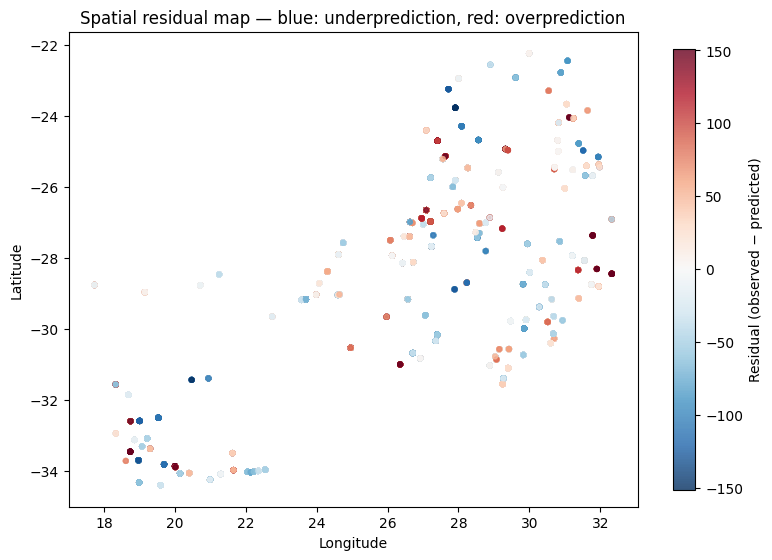

In [2]:
v = np.percentile(np.abs(residual), 98)
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(lon_arr, lat_arr, c=residual, cmap="RdBu_r", s=12, alpha=0.8, vmin=-v, vmax=v)
plt.colorbar(sc, ax=ax, label="Residual (observed − predicted)", shrink=0.8)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Spatial residual map — blue: underprediction, red: overprediction")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

# 3. Residual distribution

Plot **histogram** and **KDE** of residuals. Check **bias** (mean ≠ 0), **skewness**, and **heavy tails** — these indicate systematic or non-normal errors.

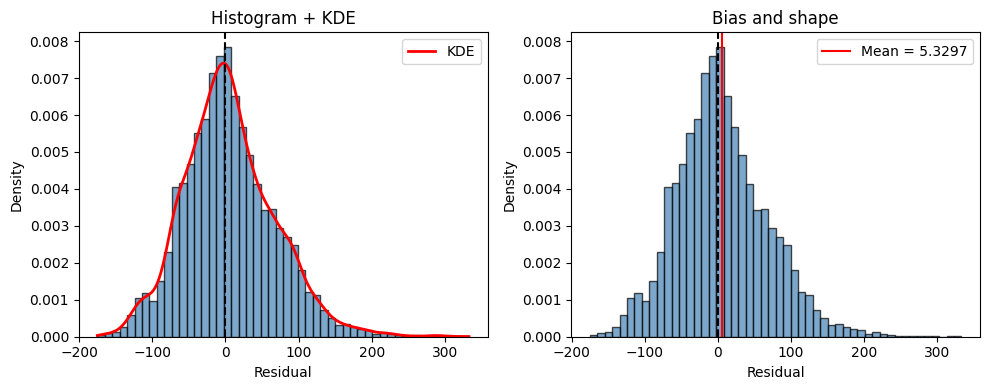

Bias (mean residual): 5.3297
Skewness: 0.4899
Kurtosis (heavy tails if > 3): 0.7861


In [3]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(residual, bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="k")
res_sorted = np.sort(residual)
axes[0].plot(res_sorted, stats.gaussian_kde(residual)(res_sorted), "r-", lw=2, label="KDE")
axes[0].axvline(0, color="k", ls="--")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Density")
axes[0].set_title("Histogram + KDE")
axes[0].legend()

axes[1].hist(residual, bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="k")
axes[1].axvline(0, color="k", ls="--")
axes[1].axvline(np.mean(residual), color="red", ls="-", label=f"Mean = {np.mean(residual):.4f}")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Density")
axes[1].set_title("Bias and shape")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Bias (mean residual): {np.mean(residual):.4f}")
print(f"Skewness: {stats.skew(residual):.4f}")
print(f"Kurtosis (heavy tails if > 3): {stats.kurtosis(residual):.4f}")

# 4. Error vs environmental variables

Plot **residuals** against key variables: **elevation**, **precipitation**, **NDVI**, **clay**, **temperature_2m**. Use scatterplots and **LOWESS** smoothing to see where the model struggles (e.g. bias in high-elevation or high-NDVI areas).

LOWESS: install statsmodels for smooth curves (pip install statsmodels). Using scatter only.


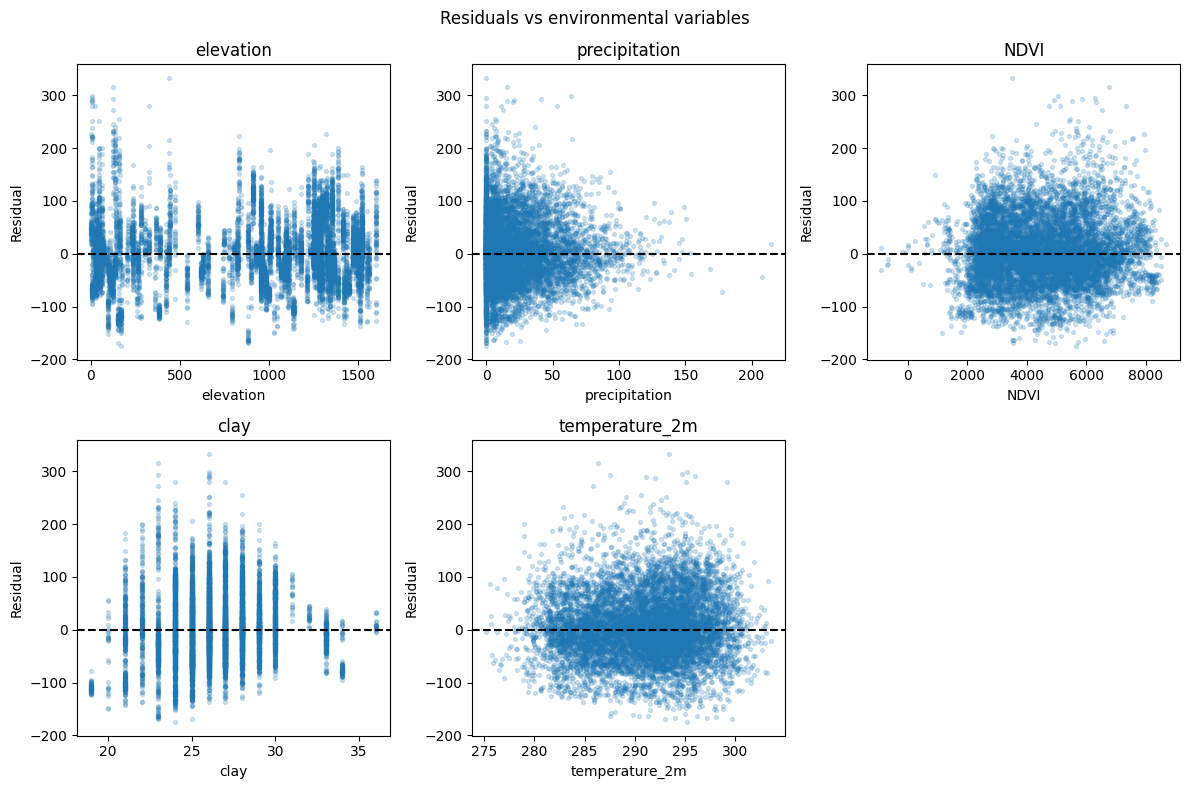

In [4]:
env_candidates = ["elevation", "precipitation", "NDVI", "clay", "temperature_2m"]
env_cols = [c for c in env_candidates if c in df.columns]
if not env_cols:
    alt = [c for c in df.columns if any(x in c.lower() for x in ["elev", "precip", "ndvi", "clay", "temp"])]
    env_cols = alt[:5]

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    use_lowess = True
except ImportError:
    use_lowess = False
    print("LOWESS: install statsmodels for smooth curves (pip install statsmodels). Using scatter only.")

n_plot = min(5, len(env_cols))
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for i, col in enumerate(env_cols[:n_plot]):
    ax = axes[i]
    x = df[col].values
    valid = np.isfinite(x) & np.isfinite(residual)
    ax.scatter(x[valid], residual[valid], alpha=0.2, s=8)
    if use_lowess and np.sum(valid) > 50:
        ord = np.argsort(x[valid])
        xs = x[valid][ord]
        ys = residual[valid][ord]
        smooth = lowess(ys, xs, frac=0.2)
        ax.plot(smooth[:, 0], smooth[:, 1], "r-", lw=2, label="LOWESS")
    ax.axhline(0, color="k", ls="--")
    ax.set_xlabel(col)
    ax.set_ylabel("Residual")
    ax.set_title(col)
    if use_lowess and np.sum(valid) > 50:
        ax.legend(loc="best", fontsize=8)
if n_plot < len(axes):
    axes[n_plot].axis("off")
plt.suptitle("Residuals vs environmental variables")
plt.tight_layout()
plt.show()

# 5. Residual spatial autocorrelation

Compute **Moran's I** on the **residuals**. If residual autocorrelation is present, the model still misses spatial structure (e.g. unmeasured spatial drivers or spatial non-stationarity).

In [5]:
def morans_i(x, coords, max_samples=2500, k_neighbors=10):
    n = len(x)
    x = np.asarray(x, dtype=float).ravel()
    coords = np.asarray(coords, dtype=float)
    if coords.shape[0] != n:
        coords = coords[:n]
    if n > max_samples:
        rng = np.random.default_rng(42)
        idx = rng.choice(n, size=max_samples, replace=False)
        x, coords = x[idx], coords[idx]
        n = len(x)
    x = x - np.nanmean(x)
    valid = np.isfinite(x)
    if np.sum(valid) < 20:
        return np.nan, np.nan
    x, coords = x[valid], coords[valid]
    n = len(x)
    d = squareform(pdist(coords, "euclidean"))
    np.fill_diagonal(d, np.inf)
    w = np.zeros_like(d)
    for j in range(n):
        nbr = np.argpartition(d[j], k_neighbors)[:k_neighbors]
        w[j, nbr] = 1.0 / (d[j, nbr] + 1e-6)
    w = (w + w.T) / 2
    W = w.sum()
    if W <= 0:
        return np.nan, np.nan
    numer = np.sum(w * np.outer(x, x))
    denom = np.sum(x ** 2)
    if denom <= 0:
        return np.nan, np.nan
    I = (n / W) * (numer / denom)
    n_perm = 99
    I_perm = []
    for _ in range(n_perm):
        x_perm = np.random.permutation(x)
        I_perm.append((n / W) * np.sum(w * np.outer(x_perm, x_perm)) / denom)
    z = (I - np.mean(I_perm)) / (np.std(I_perm) + 1e-10)
    return float(I), float(z)

coords = np.column_stack([lat_arr, lon_arr])
I_res, z_res = morans_i(residual, coords)
print(f"Moran's I (residuals): I = {I_res:.4f}, z ≈ {z_res:.2f}")
if abs(z_res) > 1.96:
    print("Residuals are spatially autocorrelated → model still misses spatial structure.")
else:
    print("Residuals show weak spatial autocorrelation → model has captured much of the spatial pattern.")

Moran's I (residuals): I = 0.6665, z ≈ 86.30
Residuals are spatially autocorrelated → model still misses spatial structure.


# 6. Feature importance

Train the model on the **full dataset** and compute **feature importance**. Plot the **top 20** features.

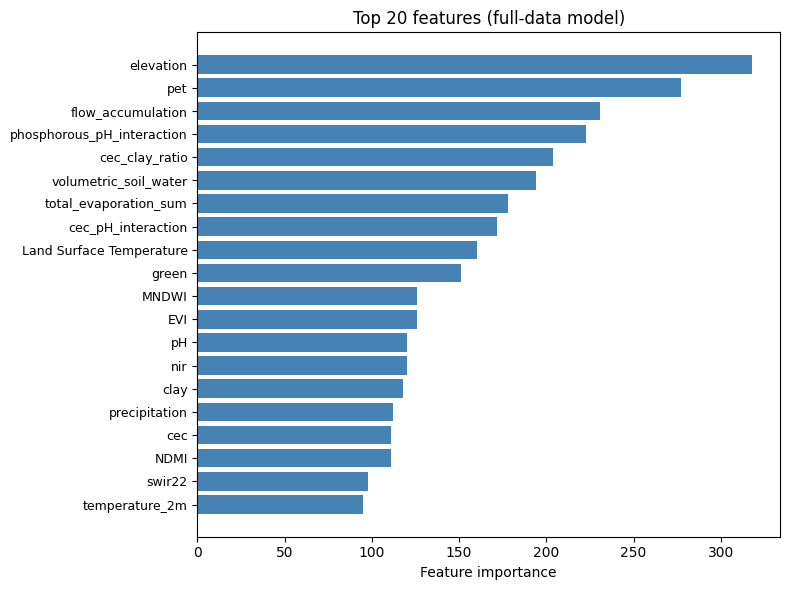

In [6]:
sc_full = StandardScaler().fit(X)
X_scaled = pd.DataFrame(sc_full.transform(X), columns=X.columns)
model_full = Model(**model_kw).fit(X_scaled, y)
imp = model_full.feature_importances_
order = np.argsort(imp)[::-1][:20]
top_names = [X.columns[i] for i in order]
top_imp = imp[order]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(20), top_imp[::-1], color="steelblue")
ax.set_yticks(range(20))
ax.set_yticklabels(top_names[::-1], fontsize=9)
ax.set_xlabel("Feature importance")
ax.set_title("Top 20 features (full-data model)")
plt.tight_layout()
plt.show()

# 7. Interpretation

## Spatial patterns of model errors
- The **residual map** (Section 2) shows where the model systematically over- or under-predicts. Clusters of same-sign residuals suggest **regional bias** (e.g. missing local drivers or process non-stationarity).
- **Residual distribution** (Section 3): non-zero mean → **bias**; skewness or heavy tails → **asymmetric or extreme errors** that may need robust loss or different predictors.

## Potential missing predictors
- If residuals correlate with an **environmental variable** (Section 4), that variable may be under-used or missing (e.g. no soil depth, no land cover). LOWESS helps spot **nonlinear** bias.
- If **Moran's I on residuals** (Section 5) is significant, the model has not fully captured spatial structure — consider **spatial features** (e.g. buffer means, distance to coast) or **spatial models**.

## Implications for generalization
- Strong **spatial autocorrelation of residuals** implies that predictions at new locations may be less reliable where similar “error regions” exist.
- **Feature importance** (Section 6) indicates which drivers the model relies on; if important features are missing in new areas, generalization will suffer.
- Use these diagnostics to target **data collection** (e.g. undersampled regions or variables) and **model improvements** (e.g. additional features, spatial terms, or regional models).